# EDA 
Goal: understand what's actually in the data — real field types, missing values,
duplicates, text quality, category balance — before going preprocessing.
Every decision in preprocessing should trace back to a finding in this notebook,
not to an assumption from the schema doc.

In [10]:
import json
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RAW_PATH = Path.cwd().parent / "data" / "raw_products.jsonl"
records = [json.loads(line) for line in RAW_PATH.open()]
print(f"Total records: {len(records)}")

Total records: 300


## 1. Field types — what actually arrives, not what the schema doc claims

This is the check that would have caught our `details` field being a JSON
*string* instead of a dict before it crashed `preprocess.py`.

In [11]:
for k, v in records[0].items():
    print(f"{k:<18} {type(v).__name__:<10} sample: {str(v)[:70]}")

main_category      str        sample: AMAZON FASHION
title              str        sample: YUEDGE 5 Pairs Men's Moisture Control Cushioned Dry Fit Casual Athleti
average_rating     float      sample: 4.6
rating_number      int        sample: 16
features           list       sample: []
description        list       sample: []
price              str        sample: None
images             dict       sample: {'hi_res': ['https://m.media-amazon.com/images/I/81XlFXImFrS._AC_UL150
videos             dict       sample: {'title': [], 'url': [], 'user_id': []}
store              str        sample: GiveGift
categories         list       sample: []
details            str        sample: {"Package Dimensions": "10.31 x 8.5 x 1.73 inches; 14.82 Ounces", "Ite
parent_asin        str        sample: B08BHN9PK5
bought_together    list       sample: []


## 2. Missing / empty values per field

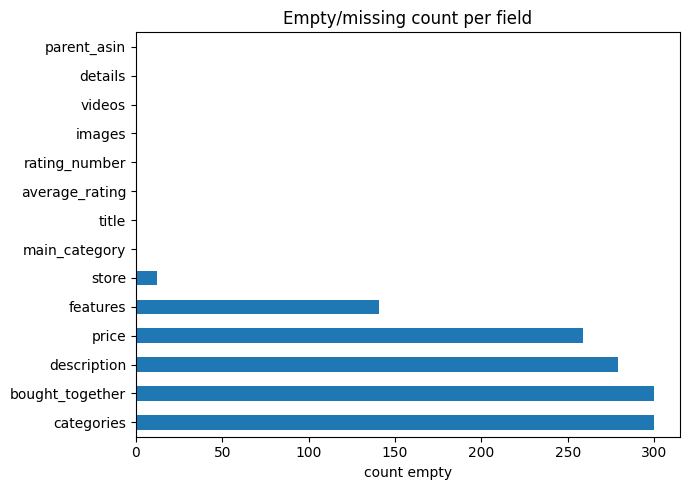

categories         300/300 empty (100%)
bought_together    300/300 empty (100%)
description        279/300 empty (93%)
price              259/300 empty (86%)
features           141/300 empty (47%)
store              12/300 empty (4%)
main_category      0/300 empty (0%)
title              0/300 empty (0%)
average_rating     0/300 empty (0%)
rating_number      0/300 empty (0%)
images             0/300 empty (0%)
videos             0/300 empty (0%)
details            0/300 empty (0%)
parent_asin        0/300 empty (0%)


In [12]:
fields = list(records[0].keys())
null_counts = {
    f: sum(1 for r in records if r.get(f) in (None, "", [], {}, "None"))
    for f in fields
}

pd.Series(null_counts).sort_values(ascending=False).plot(
    kind="barh", figsize=(7, 5), title="Empty/missing count per field"
)
plt.xlabel("count empty")
plt.tight_layout()
plt.show()

for f, n in sorted(null_counts.items(), key=lambda x: -x[1]):
    print(f"{f:<18} {n}/{len(records)} empty ({n/len(records):.0%})")

## 3. Duplicates

In [13]:
asins = [r.get("parent_asin") for r in records]
print(f"duplicate parent_asin count: {len(asins) - len(set(asins))}")

titles = [r.get("title") for r in records]
print(f"duplicate exact title count: {len(titles) - len(set(titles))}")

duplicate parent_asin count: 0
duplicate exact title count: 0


## 4. Title length distribution

Matters for `max_seq_length` when we embed `product_text` later — if titles
(plus features/description) regularly exceed the embedding model's token
limit, text gets silently truncated.

count    300.000000
mean      93.553333
std       34.262812
min       16.000000
25%       74.000000
50%       89.000000
75%      108.000000
max      207.000000
dtype: float64


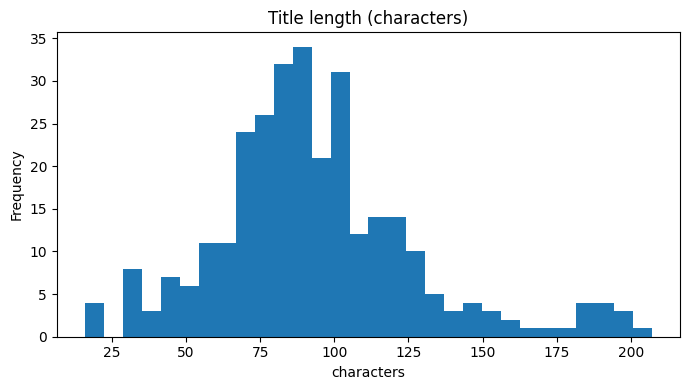

In [14]:
lengths = pd.Series([len(r.get("title") or "") for r in records])
print(lengths.describe())

lengths.plot(kind="hist", bins=30, figsize=(7, 4), title="Title length (characters)")
plt.xlabel("characters")
plt.tight_layout()
plt.show()

## 5. Category distribution — is the sample skewed?

In [15]:
cats = Counter()
for r in records:
    for c in (r.get("categories") or []):
        cats[c] += 1

empty_categories = sum(1 for r in records if not r.get("categories"))
print(f"records with empty categories list: {empty_categories}/{len(records)}")

if cats:
    pd.Series(dict(cats.most_common(10))).plot(
        kind="barh", figsize=(7, 5), title="Top 10 categories"
    )
    plt.tight_layout()
    plt.show()
else:
    print("no category data to plot")

records with empty categories list: 300/300
no category data to plot


## 6. `price` field — what type does it actually arrive as?

In [16]:
price_types = Counter(type(r.get("price")).__name__ for r in records)
print("price field python types:", dict(price_types))
print("\nsample raw values:", [r.get("price") for r in records[:10]])

price field python types: {'str': 300}

sample raw values: ['None', 'None', 'None', '29.81', '17.99', 'None', 'None', 'None', '9.99', 'None']


## 7. `details` field — dict or string?

In [17]:
details_types = Counter(type(r.get("details")).__name__ for r in records)
print("details field python types:", dict(details_types))
print("\nsample raw value:", records[0].get("details"))

details field python types: {'str': 300}

sample raw value: {"Package Dimensions": "10.31 x 8.5 x 1.73 inches; 14.82 Ounces", "Item model number": "DHES5PM21DH12", "Date First Available": "February 12, 2021"}


## 8. HTML / markup check in free-text fields

If `features`/`description` contain raw HTML tags, `preprocess.py` needs to
strip them before building `product_text` -- embedding raw `<br>` and `<li>`
tags pollutes the semantic signal.

In [18]:
import re

html_pattern = re.compile(r"<[^>]+>")
html_hits = 0
for r in records:
    text = " ".join(r.get("features") or []) + " ".join(r.get("description") or [])
    if html_pattern.search(text):
        html_hits += 1

print(f"records with HTML markup in features/description: {html_hits}/{len(records)}")

records with HTML markup in features/description: 0/300
